# Fig. 7: Expected Lead Time $\eta^+_B(x)$

In [1]:
# ML Code Inspiration from Ashesh Chattopadhyay. Unpublished code. Link: https://colab.research.google.com/drive/1aM0n7kKe80u8coGSiWa6NHr2261bkcB9?usp=sharing
# The code has been heavily augmented and modified to suit our needs, with additional code being added for other purposes.

import numpy as np
from scipy.integrate import solve_ivp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sys
import torch
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast
from torch.nn.parallel import DataParallel
import seaborn as sns
import warnings
from scipy import sparse as sps
from matplotlib import axes
import warnings
import os
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
warnings.filterwarnings("ignore", category=FutureWarning, message=".*.*")

data = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')

data = data[:,1,:]

# Normalization
mean = np.mean(data, axis=0, keepdims=True)
std = np.std(data, axis=0, keepdims=True)
data = (data - mean) / std

# Pre-processing
index = 63
num_variables = 50

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim, num_neurons):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(75, num_neurons)
        self.fc2 = nn.Linear(num_neurons, num_neurons)
        self.fc3 = nn.Linear(num_neurons, num_neurons)
        self.fc4 = nn.Linear(num_neurons, num_neurons)
        self.fc5 = nn.Linear(num_neurons, num_neurons)
        self.fc6 = nn.Linear(num_neurons, num_neurons)
        self.fc_mu = nn.Linear(num_neurons, latent_dim)
        self.fc_logvar = nn.Linear(num_neurons, latent_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + condition_dim, num_neurons)
        self.fc2 = nn.Linear(num_neurons, num_neurons)
        self.fc3 = nn.Linear(num_neurons, num_neurons)
        self.fc4 = nn.Linear(num_neurons, num_neurons)
        self.fc5 = nn.Linear(num_neurons, num_neurons)
        self.fc6 = nn.Linear(num_neurons, num_neurons)
        self.fc_output = nn.Linear(num_neurons, output_dim)

    def forward(self, z, condition):
        z = torch.cat((z, condition), dim=1)  # Concatenate latent vector and condition
        z = torch.relu(self.fc1(z))
        z = torch.relu(self.fc2(z)) + z
        z = torch.relu(self.fc3(z)) + z
        z = torch.relu(self.fc4(z)) + z
        z = torch.relu(self.fc5(z)) + z
        z = torch.relu(self.fc6(z)) + z
        output = self.fc_output(z)
        return output

# Define the VAE model
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(ConditionalVAE, self).__init__()
        self.encoder = Encoder(latent_dim, num_neurons)
        self.decoder = Decoder(latent_dim, output_dim, condition_dim, num_neurons)

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z, condition):
        return self.decoder(z, condition)

    def forward(self, x, condition):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z, condition)
        return output, mu, logvar

In [3]:
save_dir        = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths"
os.makedirs(save_dir, exist_ok=True)

latent_dim      = 32
output_dim      = 75
condition_dim   = num_variables
num_neurons     = 1024

model_path      = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/best_models_kinda/checkpoint_11"
model           = ConditionalVAE(latent_dim, output_dim, condition_dim, num_neurons).cuda()
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Loading model from checkpoint...")
model.eval()

Loading model from checkpoint...


ConditionalVAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=75, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=1024, bias=True)
    (fc4): Linear(in_features=1024, out_features=1024, bias=True)
    (fc5): Linear(in_features=1024, out_features=1024, bias=True)
    (fc6): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_mu): Linear(in_features=1024, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=82, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=1024, bias=True)
    (fc4): Linear(in_features=1024, out_features=1024, bias=True)
    (fc5): Linear(in_features=1024, out_features=1024, bias=True)
    (fc6): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_outp

In [4]:
timesteps   = 1_000_000
upper_bound = 18.59
lower_bound = 7.41
level       = 63

real_data   = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
real_data   = real_data[:timesteps, 1, :]
zonal_wind  = real_data[:, 63]

save        = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")
save        = save[:timesteps, :]

In [5]:
# Code from (Finkel et al., 2021). Link: https://github.com/justinfocus12/SHORT?tab=readme-ov-file
def first_derivative(F,lower,upper,dz):
    # Compute the first z derivatives any field
    Nt,n = F.shape
    Fz = np.zeros([Nt,n])
    Fz[:,1:-1] = (F[:,2:n] - F[:,0:n-2]) / (2*dz)
    Fz[:,0] = (F[:,1] - lower)/(2*dz)
    Fz[:,-1] = (upper - F[:,-2])/(2*dz)
    return Fz

tau = 0.25
kappa = 0.0
sigma = 1.0
state_dim = 2
dt_sim = 0.0001
obs_dim = 2 # Observable degrees of freedom
ref_alt = 30.0
hB_d = 38.5
physical_params = dict({
    'tau': tau,
    'kappa': kappa,
    'sigma': sigma,
    'state_dim': state_dim,
    'obs_dim': obs_dim,
    'dt_sim': dt_sim,
    'ref_alt': ref_alt,
    'hB_d': hB_d,
    'du_per_day': 1.0,
    'dt_sim': 0.005,
    })

q = {
           'rad': 6370.0e3, 'g': 9.82, 'phi0': np.pi/3, 
           'sx': 2, 'zB_d': 0.0, 'zT_d': 70.0e3, 'H': 7.0e3, 
           'Omega': 2*np.pi/(24*3600), 'Nsq_d': 4.0e-4, 'ideal_gas_constant': 8.314,
           'hB_d': physical_params['hB_d'], 'Nz': 26, 'length': 2.5e5, 'time': 24*3600.0,
           'du_per_day': physical_params['du_per_day'], 'dt_sim': physical_params['dt_sim'],
        }

n = q['Nz']+1 #Number of points including boundaries
q['state_dim'] = 3*(q['Nz']-1)
#Dimensional variables
q['f0_d'] = 2*q['Omega']*np.sin(q['phi0'])
q['k_d'] = q['sx']/(q['rad']*np.cos(q['phi0']))
q['dz_d'] = (q['zT_d']-q['zB_d'])/q['Nz']
q['z_d'] = np.linspace(q['zB_d'],q['zT_d'],q['Nz']+1)
q['Psi0_d'] = q['g']*q['hB_d']/q['f0_d']
q['fn'] = q['f0_d']**2/q['Nsq_d']
#Dimensionless variables
q['Gsq'] = 1.0/(q['length']**2/q['H']**2*q['fn'])
q['k'] = q['k_d']*q['length']
q['dz'] = q['dz_d']/q['H']
q['z'] = q['z_d']/q['H']
q['Psi0'] = q['Psi0_d']*q['time']/q['length']**2
# End of code from (Finkel et al., 2021)

# Computing the integrated heat flux function with code from (Finkel et al., 2021),
# but placing it is a separate function for readability and cohesion.

def ihf_function(data):

    n = q['Nz']-1
    x = data  # Use the 'save' array as 'x'
    Nt = len(x)
    heat_flux = np.ones([Nt,n+1])
    heat_flux *= q['k']

    # Now it has to be multiplied by vertical derivatives
    Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
    Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
    Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
    heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
    heat_flux[:,0] *= q['Psi0']*Yz0
    heat_flux *= np.exp(-q['z'][:-1])
    ihf = np.zeros((Nt,n))
    ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
    for i in range(1,n):
        ihf[:,i] = ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']
    
    return ihf

In [6]:
timesteps = 1_000_000

# Holton-Mass data
real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
real_data = real_data[:timesteps, 1, :]
zonal_wind = real_data[:, 63]
real_ihf = ihf_function(real_data)

# Emulator data
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")
save = save[:timesteps, :]
ihf = ihf_function(save)

def lead_time_matrix(d1, d2, T_idxs, A_idxs, B_idxs, 
                     bs1, bs2, n_bins):
    """
    Create a lead time matrix that tracks average lead times from A to B.
    
    Args:
        d1: Zonal wind values
        d2: IHF values  
        T_idxs: Indices of points in transition region
        A_idxs: Indices of points in state A
        B_idxs: Indices of points in state B
        bs1: bounds for zonal wind
        bs2: bounds for IHF
        n_bins: Number of bins
    
    Returns:
        lead_time_matrix: Matrix with average lead times
        edg1, edg2: Bin edges for plotting"""
    
    lead_times_sum = np.zeros((n_bins, n_bins))  # Sum of lead times
    lead_times_count = np.zeros((n_bins, n_bins))  # Count of transitions
    lead_time_matrix = np.full((n_bins, n_bins), np.nan)
    
    # Create bins
    edg1 = np.linspace(lower_bound, upper_bound, n_bins + 1)
    edg2 = np.linspace(bs2[0], bs2[1], n_bins + 1)
    bsize1 = (upper_bound - lower_bound) / n_bins
    bsize2 = (bs2[1] - bs2[0]) / n_bins
    
    for i in range(len(d1)):
        if i in T_idxs:
            u_val = d1[i]
            ihf_val = d2[i]
            
            # Find bin indices
            u_bin = int((u_val - lower_bound) / bsize1)
            ihf_bin = int((ihf_val - bs2[0]) / bsize2)
            
            # Ensure bins are within bounds
            u_bin = min(max(u_bin, 0), n_bins - 1)
            ihf_bin = min(max(ihf_bin, 0), n_bins - 1)
            
            # Count total visits
            future_window = min(1000, len(d1) - i - 1)
            
            for j in range(1, future_window + 1):
                future_idx = i + j
                if future_idx in B_idxs:
                    lead_times_sum[u_bin, ihf_bin] += j
                    lead_times_count[u_bin, ihf_bin] += 1
                    break
                elif future_idx in A_idxs:
                    # Went back to A, don't count as transition to B
                    break

    mask = lead_times_count > 0
    lead_time_matrix[mask] = lead_times_sum[mask] / lead_times_count[mask]

    return lead_times_sum, lead_times_count, lead_time_matrix, edg1, edg2

# Real U(30)
rmin1   = np.min(real_data[:, level])
rmax1   = np.max(real_data[:, level])
rud     = real_data[:, level]

# Real IHF(30)
rmin3   = np.min(real_ihf[:, level-50])
rmax3   = np.max(real_ihf[:, level-50])
ruhf     = real_ihf[:, level-50]

# Model U(30)
min1   = np.min(save[:, level])
max1   = np.max(save[:, level])
mud     = save[:, level]

# Model IHF(30)
min3   = np.min(ihf[:, level-50])
max3   = np.max(ihf[:, level-50])
muhf     = ihf[:, level-50]

# Real Transition region indices
cd = (real_data[:, level] < upper_bound) & (real_data[:, level] > lower_bound)
rT_idxs = np.where(cd)[0]

# Real State A and B indices
cd_A = (real_data[:, level] > upper_bound)
cd_B = (real_data[:, level] < lower_bound)
rA_idxs = np.where(cd_A)[0]
rB_idxs = np.where(cd_B)[0]

# Model Transition region indices
mcd = (save[:, level] < upper_bound) & (save[:, level] > lower_bound)
mT_idxs = np.where(mcd)[0]

# Model State A and B indices
mcd_A = (save[:, level] > upper_bound)
mcd_B = (save[:, level] < lower_bound)
mA_idxs = np.where(mcd_A)[0]
mB_idxs = np.where(mcd_B)[0]

lead_bins = 50

In [ ]:
condition = (rud > lower_bound) & (rud < upper_bound)
indices = np.where(condition)[0]
lead_times_sum_r, lead_times_count_r, rlead_times, r1_edges, r2_edges = lead_time_matrix(rud, ruhf, rT_idxs, rA_idxs, rB_idxs, [rmin1, rmax1], [rmin3, rmax3], n_bins=lead_bins)

condition = (mud > lower_bound) & (mud < upper_bound)
indices = np.where(condition)[0]
lead_times_sum_m, lead_times_count_m, mlead_times, m1_edges, m2_edges = lead_time_matrix(mud, muhf, mT_idxs, mA_idxs, mB_idxs, [min1, max1], [min3, max3], n_bins=lead_bins)

# Real data committor
r1, r2 = np.meshgrid(r1_edges[:-1], r2_edges[:-1], indexing='ij')
# Mask NaN values for white background
rlead_masked = np.ma.masked_invalid(rlead_times)

# Model data committor
m1, m2 = np.meshgrid(m1_edges[:-1], m2_edges[:-1], indexing='ij')
# Mask NaN values for white background
mlead_masked = np.ma.masked_invalid(mlead_times)

np.save(f"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/plot_data/hm_lead_{lead_bins}_bins_{timesteps}.npy", (lead_times_sum_r, lead_times_count_r, rlead_masked, r1, r2))
np.save(f"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/plot_data/em_lead_{lead_bins}_bins_{timesteps}.npy", (lead_times_sum_m, lead_times_count_m, mlead_masked, m1, m2))

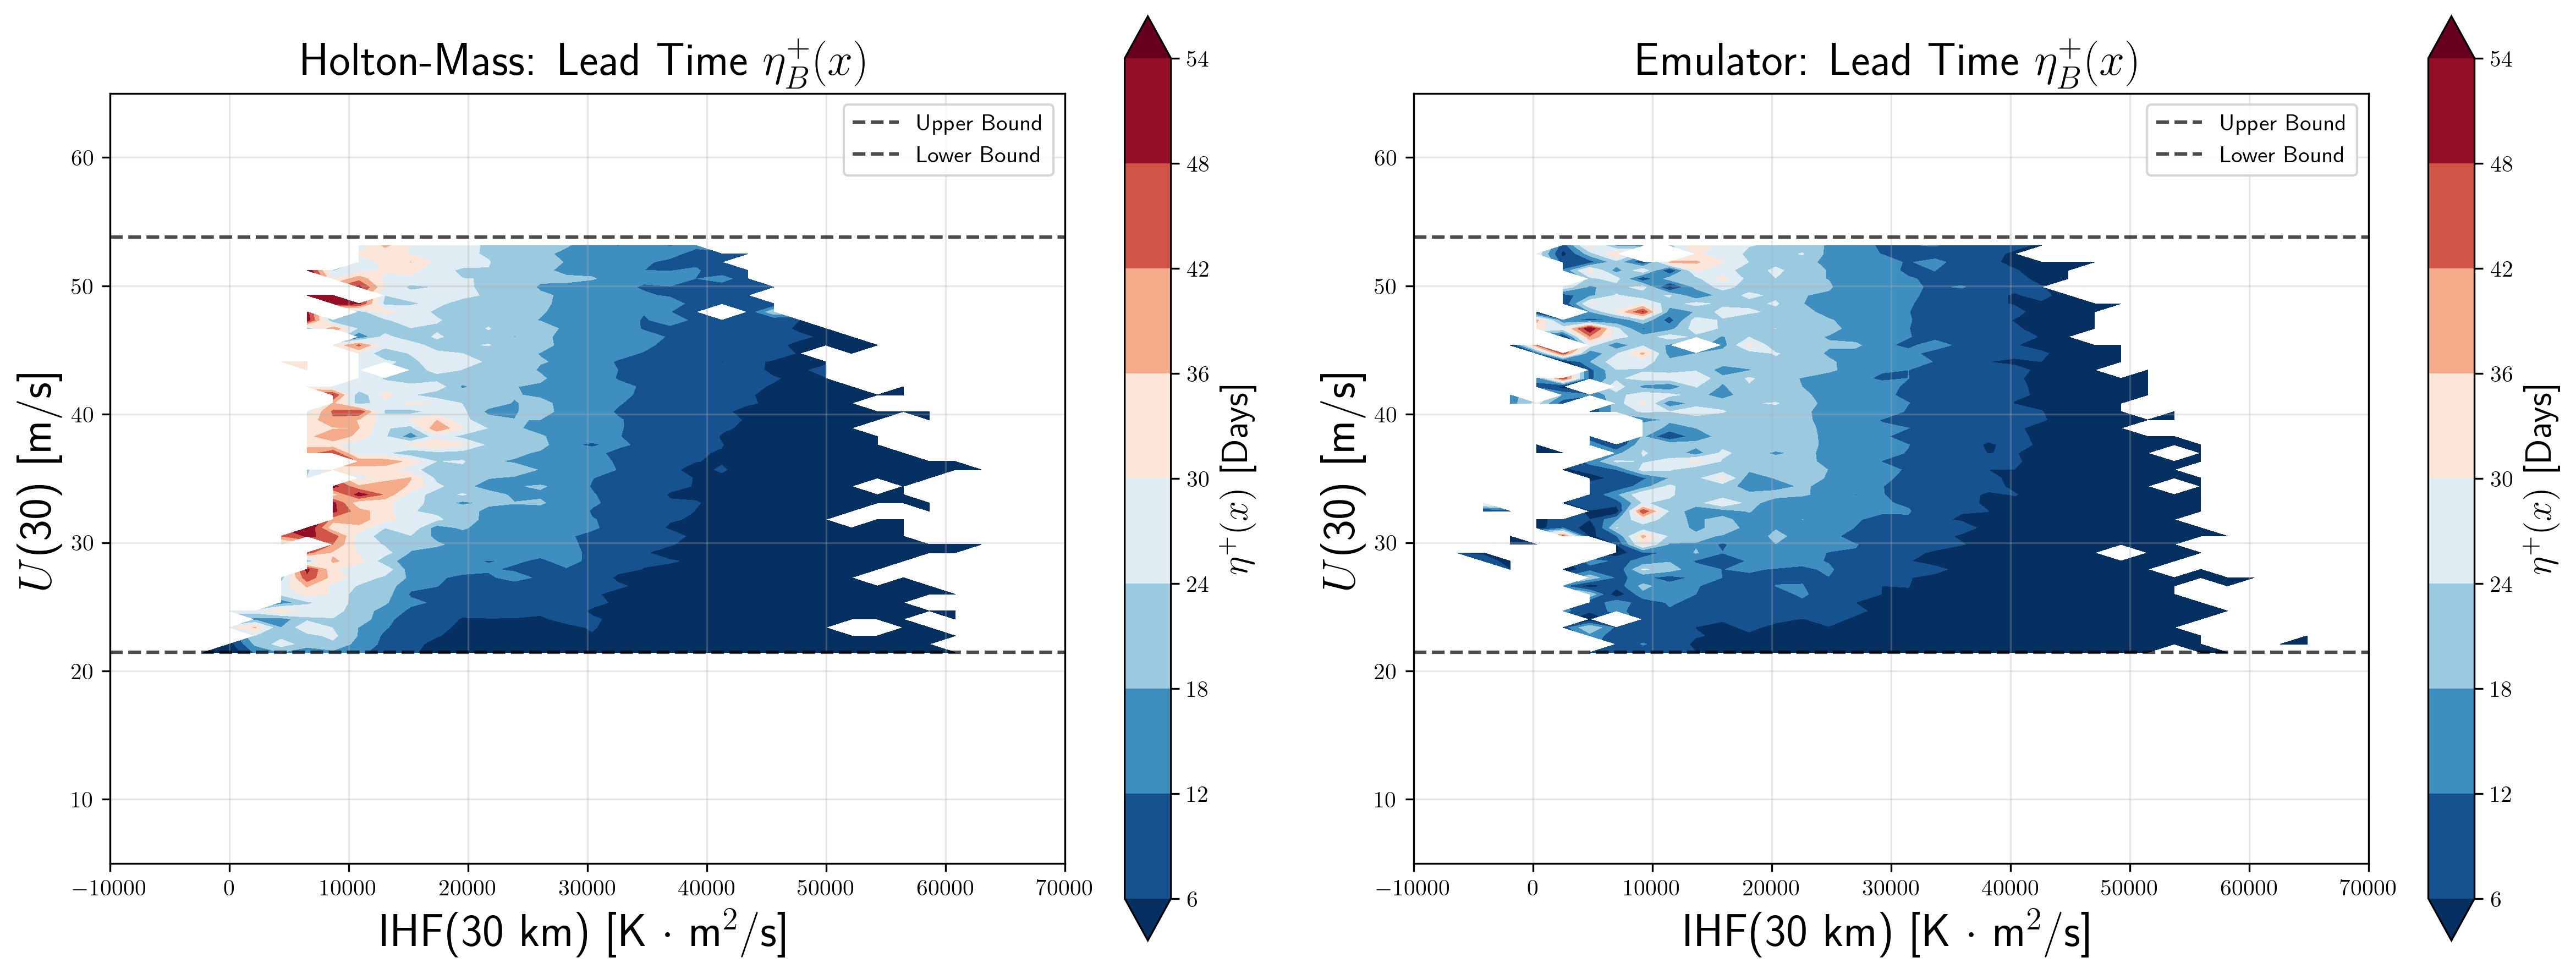

In [7]:
lead_times_sum_r, lead_times_count_r, rlead_masked, r1, r2 = np.load(f"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/plot_data/hm_lead_{lead_bins}_bins_{timesteps}.npy")
lead_times_sum_m, lead_times_count_m, mlead_masked, m1, m2 = np.load(f"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/plot_data/em_lead_{lead_bins}_bins_{timesteps}.npy")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Get the RdBu_r colormap
cmap = plt.cm.RdBu_r
# Set the color for bad/missing values to white
cmap.set_bad(color='white')

im1 = axes[0].contourf(r2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                       r1.T * (q['length']/q['time']), rlead_masked.T, 
                    levels=8, cmap=cmap, extend='both')

axes[0].set_xlabel(r"IHF(30 km) [K $\cdot$ m$^2$/s]", fontsize=20)
axes[0].set_ylabel(r'$U$(30) [m/s]', fontsize=20)
axes[0].set_title(r'Holton-Mass: Lead Time $\eta^+_B(x)$', fontsize=20, pad =8)
axes[0].set_xlim(-10000, 70000)
axes[0].set_ylim(5, 65)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

cbar1 = plt.colorbar(im1, ax=axes[0], shrink = 1.2)
cbar1.set_label(r'$\eta^+(x)$ [Days]', fontsize=16)

# Add boundary lines
axes[0].axhline(y=upper_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[0].axhline(y=lower_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[0].legend()

im2 = axes[1].contourf(m2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                       m1.T * (q['length']/q['time']), mlead_masked.T, 
                    levels=9, cmap=cmap, extend='both')

axes[1].set_xlabel(r"IHF(30 km) [K $\cdot$ m$^2$/s]", fontsize=20)
axes[1].set_ylabel(r'$U$(30) [m/s]', fontsize=20)
axes[1].set_title(r'Emulator: Lead Time $\eta^+_B(x)$', fontsize=20, pad =8)
axes[1].set_xlim(-10000, 70000)
axes[1].set_ylim(5, 65)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('white')

cbar2 = plt.colorbar(im2, ax=axes[1], shrink = 1.2)
cbar2.set_label(r'$\eta^+(x)$ [Days]', fontsize=16)

# Add boundary lines
axes[1].axhline(y=upper_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[1].axhline(y=lower_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[1].legend()

plt.tight_layout()
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/lead_time_50_bins.png")
plt.show()